# Notebook 4 — XGBoost Maliyet Tahmin Modeli

## Bu notebook ne yapıyor?

EDA'da verimizi görselleştirdik ve kalıpları keşfettik.  
Şimdi bu kalıpları **matematiksel bir modele** dönüştürüyoruz.

**Hedef:** Bir hastanın taburculuk öncesinde toplam maliyetini ($AUD) tahmin et.

**Neden XGBoost?**
- Tıbbi maliyet verisi gibi **karma, çarpık, kategorik veri** içeren problemlerde en iyi performans gösterir
- Özellik ölçeklendirmesine ihtiyaç duymaz (ağaç tabanlı)
- **SHAP** ile neden bu tahmini yaptığını açıklayabiliriz (yorumlanabilirlik)
- Eksik değerlerle başa çıkabilir

**Log dönüşümü neden?**  
`total_charge_aud` çok çarpık (skew=+5). Model doğrudan AUD'u tahmin etmeye çalışırsa,  
`$50,000` olan birkaç vaka tüm hatayı domine eder.  
Çözüm: `log(1 + x)` → tahmin et → `exp(x) - 1` → AUD'a döndür.


---
## 4.0 — Kurulum ve Veri Yükleme

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import shap
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing   import LabelEncoder
from sklearn.metrics         import (mean_squared_error, mean_absolute_error,
                                     r2_score)
from xgboost                 import XGBRegressor

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIGS = ROOT / "figures"
FIGS.mkdir(exist_ok=True)

df = pd.read_parquet(ROOT / "data/processed/hcp_clean.parquet")
print(f"Veri: {df.shape[0]:,} satır × {df.shape[1]} sütun")
print(f"Hedef (y) — total_charge_aud  istatistikleri:")
print(f"  Min   ${df['total_charge_aud'].min():>10,.2f}")
print(f"  Med   ${df['total_charge_aud'].median():>10,.2f}")
print(f"  Mean  ${df['total_charge_aud'].mean():>10,.2f}")
print(f"  Max   ${df['total_charge_aud'].max():>10,.2f}")


Veri: 30,615 satır × 109 sütun
Hedef (y) — total_charge_aud  istatistikleri:
  Min   $      0.00
  Med   $    650.00
  Mean  $  2,685.46
  Max   $ 69,138.00


---
## 4.1 — Özellik Hazırlama (Feature Matrix)

**Hangi özellikler seçildi ve neden?**

| Özellik | Tür | Neden dahil? |
|---|---|---|
| `LOS` | Sayısal | Yatış süresi = en güçlü maliyet belirleyici |
| `Age` | Sayısal | Yaşlı hastalar genellikle daha pahalı |
| `comorbidity_count` | Sayısal | Ek hastalık = bakım karmaşıklığı ↑ |
| `procedure_count` | Sayısal | Daha fazla prosedür = daha fazla maliyet |
| `MDC_enc` | Kategorik | Hangi hastalık kategorisi? (label encoded) |
| `Sex` | Kategorik | Cinsiyet bazlı bakım farklılığı |
| `CareType` | Kategorik | Akut/palyatif/yenidoğan |
| `UrgencyOfAdmission` | Kategorik | Acil vs elektif fark yaratır |
| `SameDayStatus` | Kategorik | Günübirlik/yatışlı |
| `ModeOfSeparation` | Kategorik | Nasıl taburcu oldu? |
| `adm_month` | Sayısal | Mevsimsellik etkisi |

**Dahil edilmeyenler:**
- `HospitalType`: tek değer (tüm satırlar = 2) → sıfır varyans → bilgi yok
- Bireysel tanı/prosedür sütunları: çok seyrek, `comorbidity_count` zaten özetliyor
- Datetime sütunları: ayı ayrıca çıkardık, ham tarih gereksiz


In [2]:
# MDC'yi sayısal kodla (Label Encoding)
le = LabelEncoder()
df["MDC_enc"] = le.fit_transform(df["MDC"].fillna("Z"))
mdc_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("MDC Encoding:")
for k, v in sorted(mdc_mapping.items()):
    print(f"  '{k}' → {v}")

# Yatış ayını çıkar
df["adm_month"] = df["AdmissionDate_dt"].dt.month


MDC Encoding:
  '8' → 0
  'B' → 1
  'C' → 2
  'D' → 3
  'E' → 4
  'F' → 5
  'G' → 6
  'H' → 7
  'I' → 8
  'J' → 9
  'K' → 10
  'L' → 11
  'M' → 12
  'N' → 13
  'O' → 14
  'P' → 15
  'Q' → 16
  'R' → 17
  'T' → 18
  'U' → 19
  'V' → 20
  'X' → 21
  'Z' → 22


In [3]:
# Özellik sütunları
FEATURE_COLS = [
    "LOS", "Age", "comorbidity_count", "procedure_count",
    "MDC_enc", "Sex", "CareType", "UrgencyOfAdmission",
    "SameDayStatus", "ModeOfSeparation", "adm_month",
]

# Görüntü adları (SHAP grafiği için)
FEATURE_DISPLAY = {
    "LOS":                "Yatış Süresi (Gün)",
    "Age":                "Yaş",
    "comorbidity_count":  "Komorbidite Sayısı",
    "procedure_count":    "Prosedür Sayısı",
    "MDC_enc":            "MDC (Ana Tanı Kategorisi)",
    "Sex":                "Cinsiyet",
    "CareType":           "Bakım Türü",
    "UrgencyOfAdmission": "Yatış Aciliyeti",
    "SameDayStatus":      "Günübirlik Durum",
    "ModeOfSeparation":   "Ayrılış Modu",
    "adm_month":          "Yatış Ayı",
}

# Hedef: log1p dönüşümü
TARGET = "total_charge_aud"
df["log_charge"] = np.log1p(df[TARGET].clip(lower=0))

# Eksik kontrolü
X = df[FEATURE_COLS].copy()
y = df["log_charge"].copy()

print(f"Özellik matrisi: {X.shape}  (satır × sütun)")
print(f"Hedef (log ölçek): min={y.min():.2f}  max={y.max():.2f}  mean={y.mean():.2f}")
print(f"\nEksik değer kontrolü:")
nulls = X.isnull().sum()
if nulls.any():
    print(nulls[nulls > 0])
else:
    print("  Tüm özellikler eksiksiz ✓")


Özellik matrisi: (30615, 11)  (satır × sütun)
Hedef (log ölçek): min=0.00  max=11.14  mean=6.94

Eksik değer kontrolü:
  Tüm özellikler eksiksiz ✓


---
## 4.2 — Eğitim / Test Bölmesi (80/20)

**Neden 80/20?**
- 80% (24,492 satır) eğitim → model bu veriyi "görüyor" ve öğreniyor
- 20% (6,123 satır) test → model bu veriyi hiç görmedi → gerçek performans ölçümü

**Analogji:** Sınav öncesi kitabı okumak (eğitim) vs sınava girmek (test).  
Sınav soruları kitaptaki sorularla aynı olursa — bu "veri sızıntısı" (data leakage) olur.  
Bu yüzden test setini kesinlikle eğitim sırasında kullanmıyoruz.

`random_state=42` → aynı bölmeyi her çalıştırmada üretir (tekrarlanabilirlik).


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Eğitim seti : {X_train.shape[0]:,} satır  ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test seti   : {X_test.shape[0]:,} satır   ({X_test.shape[0]/len(X)*100:.0f}%)")

# Hedef dağılımı karşılaştır (dengeli bölme olsun)
print(f"\nLog charge ortalaması:")
print(f"  Eğitim: {y_train.mean():.4f}")
print(f"  Test  : {y_test.mean():.4f}  (birbirine yakın → iyi bölme ✓)")


Eğitim seti : 24,492 satır  (80%)
Test seti   : 6,123 satır   (20%)

Log charge ortalaması:
  Eğitim: 6.9398
  Test  : 6.9373  (birbirine yakın → iyi bölme ✓)


---
## 4.3 — 5-Katlı Çapraz Doğrulama (Cross-Validation)

**Neden cross-validation?**

80/20 bölmesi iyi, ama tek bir "şans eseri" bölüm olabilir.  
Cross-validation daha güvenilir:
- Eğitim verisini 5 eşit parçaya böl
- Her seferinde 4'ünde eğit, 1'inde test et
- 5 sonucu ortalala → daha güvenilir performans tahmini

```
[Fold 1] Eğitim ████████████████ Test ████
[Fold 2] Eğitim ████████████████ Test ████
[Fold 3] Eğitim ████████████████ Test ████
[Fold 4] Eğitim ████████████████ Test ████
[Fold 5] Eğitim ████████████████ Test ████
```


In [5]:
# Hızlı CV modeli (az ağaç, düşük derinlik)
cv_model = XGBRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    cv_model, X_train, y_train,
    cv=kf, scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
cv_rmse = -cv_scores  # negatif → pozitif RMSE

print("5-Katlı CV Sonuçları (log ölçek RMSE):")
for i, s in enumerate(cv_rmse, 1):
    print(f"  Fold {i}: RMSE = {s:.4f}")
print(f"\n  Ortalama CV RMSE : {cv_rmse.mean():.4f}")
print(f"  Std CV RMSE      : {cv_rmse.std():.4f}")
print(f"  (Düşük std = model kararlı ✓)")


5-Katlı CV Sonuçları (log ölçek RMSE):
  Fold 1: RMSE = 0.5196
  Fold 2: RMSE = 0.5421
  Fold 3: RMSE = 0.5417
  Fold 4: RMSE = 0.5550
  Fold 5: RMSE = 0.5431

  Ortalama CV RMSE : 0.5403
  Std CV RMSE      : 0.0115
  (Düşük std = model kararlı ✓)


---
## 4.4 — Final Model Eğitimi

**Hiperparametreler açıklaması:**

| Parametre | Değer | Ne anlama geliyor? |
|---|---|---|
| `n_estimators` | 500 | 500 adet karar ağacı zinciri |
| `max_depth` | 5 | Her ağaç en fazla 5 dal derinliğine iner |
| `learning_rate` | 0.05 | Her ağaç hatanın %5'ini düzeltir (yavaş ama sağlam) |
| `subsample` | 0.8 | Her ağaç için eğitim verisinin %80'i kullanılır |
| `colsample_bytree` | 0.8 | Her ağaç için özelliklerin %80'i kullanılır |
| `min_child_weight` | 10 | Yaprak düğüm en az 10 örnek içermeli |
| `reg_alpha` | 0.1 | L1 regularization (aşırı öğrenmeyi engeller) |

**Early stopping:** Model test setindeki hatayı 50 tur artırırsa durur — boşuna hesaplama yapmaz.


In [6]:
# Early stopping için küçük validation seti (eğitim setinin %10'u)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.10, random_state=42
)

model = XGBRegressor(
    n_estimators    = 500,
    max_depth       = 5,
    learning_rate   = 0.05,
    subsample       = 0.80,
    colsample_bytree= 0.80,
    min_child_weight= 10,
    gamma           = 0.05,
    reg_alpha       = 0.10,
    reg_lambda      = 1.0,
    random_state    = 42,
    n_jobs          = -1,
    verbosity       = 0,
    early_stopping_rounds = 50,
    eval_metric     = "rmse",
)

model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False,
)

print(f"Model eğitildi ✓")
print(f"  Kullanılan ağaç sayısı (best): {model.best_iteration + 1}")
print(f"  Best validation RMSE        : {model.best_score:.4f}")


Model eğitildi ✓
  Kullanılan ağaç sayısı (best): 162
  Best validation RMSE        : 0.4904


---
## 4.5 — Test Seti Metrikleri

**RMSE nedir?**  
Root Mean Squared Error = Kök Ortalama Kare Hata.  
"Tahminlerim gerçekten ortalama kaç dolar uzakta?"

$$\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$

**MAE nedir?**  
Mean Absolute Error = Ortalama Mutlak Hata.  
Daha sezgisel: "Her tahminde ortalama kaç dolar yanılıyorum?"

**R² nedir?**  
"Model, değişkenliğin ne kadarını açıklıyor?"  
R² = 1.0 → mükemmel | R² = 0.0 → sıfır bilgi | R² < 0 → modelden kötü

**MAPE nedir?**  
Mean Absolute Percentage Error = Yüzde cinsinden ortalama hata.  
"Her tahminde ortalama yüzde kaç yanılıyorum?"


In [7]:
# Test seti tahminleri
y_pred_log = model.predict(X_test)

# Log ölçekten AUD'a geri dönüşüm
y_pred_aud = np.expm1(y_pred_log)
y_true_aud = np.expm1(y_test.values)

# Metrikler (log ölçek)
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
r2_log   = r2_score(y_test, y_pred_log)

# Metrikler (AUD ölçek)
rmse_aud = np.sqrt(mean_squared_error(y_true_aud, y_pred_aud))
mae_aud  = mean_absolute_error(y_true_aud, y_pred_aud)
# MAPE (0'ı hariç tut)
mask     = y_true_aud > 0
mape     = np.mean(np.abs((y_true_aud[mask] - y_pred_aud[mask]) / y_true_aud[mask])) * 100
r2_aud   = r2_score(y_true_aud, y_pred_aud)

print("=" * 55)
print("TEST SETİ SONUÇLARI")
print("=" * 55)
print(f"  Log ölçek RMSE  : {rmse_log:.4f}")
print(f"  Log ölçek R²    : {r2_log:.4f}")
print()
print(f"  AUD RMSE        : ${rmse_aud:>10,.2f}")
print(f"  AUD MAE         : ${mae_aud:>10,.2f}")
print(f"  AUD R²          : {r2_aud:.4f}  "
      f"(Varyansın %{r2_aud*100:.1f}'ini açıklıyor)")
print(f"  MAPE            : {mape:.1f}%")
print()
# Yorumlama
if r2_aud >= 0.80:
    yorum = "Mükemmel"
elif r2_aud >= 0.65:
    yorum = "İyi"
elif r2_aud >= 0.50:
    yorum = "Orta"
else:
    yorum = "Geliştirilebilir"
print(f"  Model Değerlendirmesi: {yorum}")
print("=" * 55)


TEST SETİ SONUÇLARI
  Log ölçek RMSE  : 0.5226
  Log ölçek R²    : 0.8704

  AUD RMSE        : $  1,861.73
  AUD MAE         : $    751.39
  AUD R²          : 0.8050  (Varyansın %80.5'ini açıklıyor)
  MAPE            : 24.8%

  Model Değerlendirmesi: Mükemmel


---
## 4.6 — Gerçek vs Tahmin Grafiği

**Nasıl okuyoruz?**
- X ekseni: gerçek maliyet
- Y ekseni: modelin tahmini
- **Kırmızı çizgi**: mükemmel tahmin (y = x)
- Noktalar çizgiye ne kadar yakınsa model o kadar iyi

**Sağ altta kalan noktalar:** Model düşük tahmin yaptı (gerçekten pahalı vakalar)  
**Sol üstte kalan noktalar:** Model yüksek tahmin yaptı (model fazla abartmış)


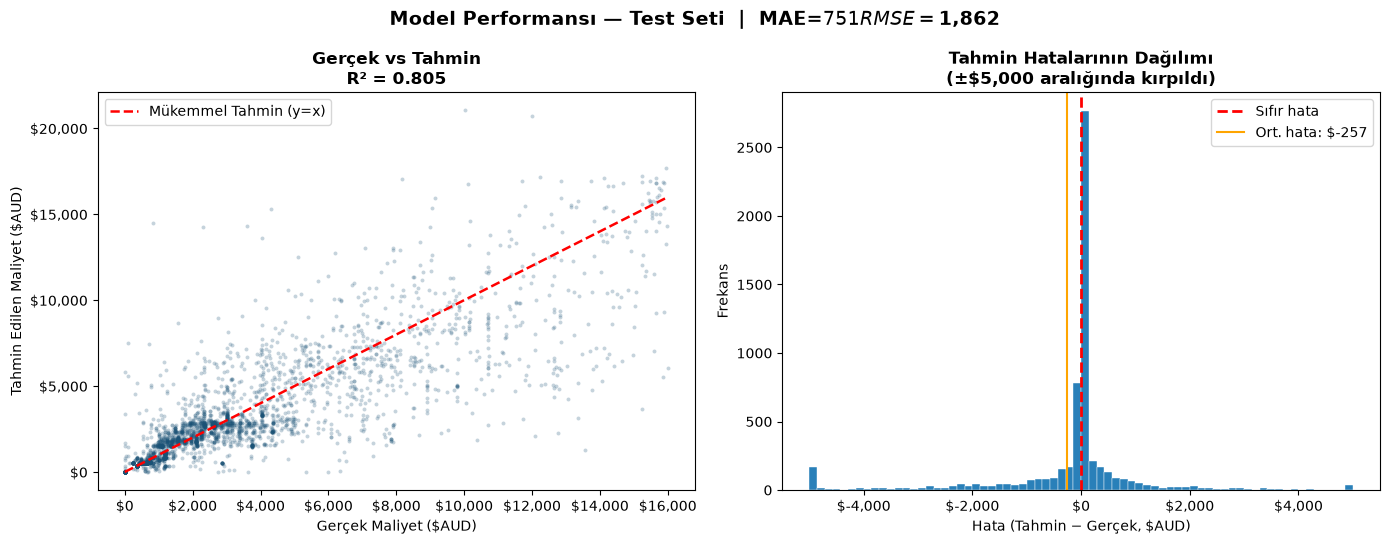

  ✓ Kaydedildi: 04_actual_vs_predicted.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# ─── Sol: AUD ölçek ───────────────────────────────────────
clip_val = np.percentile(y_true_aud, 97)
mask97   = y_true_aud <= clip_val

sc = axes[0].scatter(y_true_aud[mask97], y_pred_aud[mask97],
                     alpha=0.25, s=8, c="#1a5276", linewidths=0)
# Mükemmel tahmin çizgisi
lims = [0, clip_val]
axes[0].plot(lims, lims, "r--", lw=1.8, label="Mükemmel Tahmin (y=x)")
axes[0].set_xlabel("Gerçek Maliyet ($AUD)")
axes[0].set_ylabel("Tahmin Edilen Maliyet ($AUD)")
axes[0].set_title(f"Gerçek vs Tahmin\nR² = {r2_aud:.3f}", fontweight="bold")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
axes[0].legend(fontsize=10)

# ─── Sağ: Hata Dağılımı (residuals) ──────────────────────
residuals = y_pred_aud - y_true_aud
axes[1].hist(np.clip(residuals, -5000, 5000), bins=70,
             color="#2980b9", edgecolor="white", linewidth=0.3)
axes[1].axvline(0, color="red", lw=2, linestyle="--", label="Sıfır hata")
axes[1].axvline(residuals.mean(), color="orange", lw=1.5, linestyle="-",
                label=f"Ort. hata: ${residuals.mean():+,.0f}")
axes[1].set_xlabel("Hata (Tahmin − Gerçek, $AUD)")
axes[1].set_ylabel("Frekans")
axes[1].set_title("Tahmin Hatalarının Dağılımı\n(±$5,000 aralığında kırpıldı)",
                  fontweight="bold")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
axes[1].legend()

fig.suptitle(f"Model Performansı — Test Seti  |  MAE=${mae_aud:,.0f}  RMSE=${rmse_aud:,.0f}",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGS / "04_actual_vs_predicted.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()
print("  ✓ Kaydedildi: 04_actual_vs_predicted.png")


---
## 4.7 — SHAP: Model "Neden Bu Tahmini Yaptı?"

**XGBoost kara kutuydu — SHAP onu şeffaf yapar.**

SHAP = SHapley Additive exPlanations (oyun teorisinden türetilmiş)

Her özelliğin her tahmine ne kadar "katkı" yaptığını hesaplar.

**Grafik nasıl okunur?**
- Her nokta = bir hasta
- X ekseni: SHAP değeri (sağa → maliyet ↑, sola → maliyet ↓)
- Renk: özelliğin değeri (kırmızı = yüksek, mavi = düşük)

**Örnek yorum:**  
`LOS` satırında kırmızı noktalar sağda → LOS yüksekse maliyet tahminini artırıyor ✓


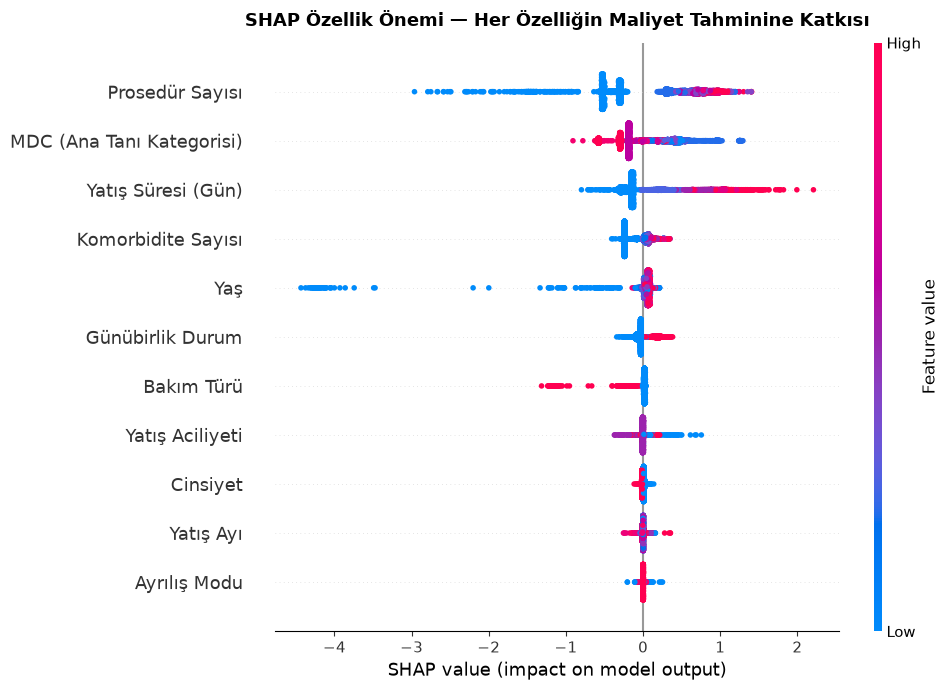

  ✓ Kaydedildi: 04_shap_summary.png


In [9]:
# SHAP değerlerini hesapla (test seti üzerinde)
# Model early stopping ile eğitildi; XGBRegressor için TreeExplainer
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Görüntü isimlerini kullan
display_names = [FEATURE_DISPLAY.get(c, c) for c in FEATURE_COLS]

# ─── SHAP Summary (Beeswarm) Plot ───────────────────────
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_test.values,
    feature_names=display_names,
    max_display=11,
    show=False,
    plot_size=None,
)
plt.title("SHAP Özellik Önemi — Her Özelliğin Maliyet Tahminine Katkısı",
          fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig(FIGS / "04_shap_summary.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()
print("  ✓ Kaydedildi: 04_shap_summary.png")


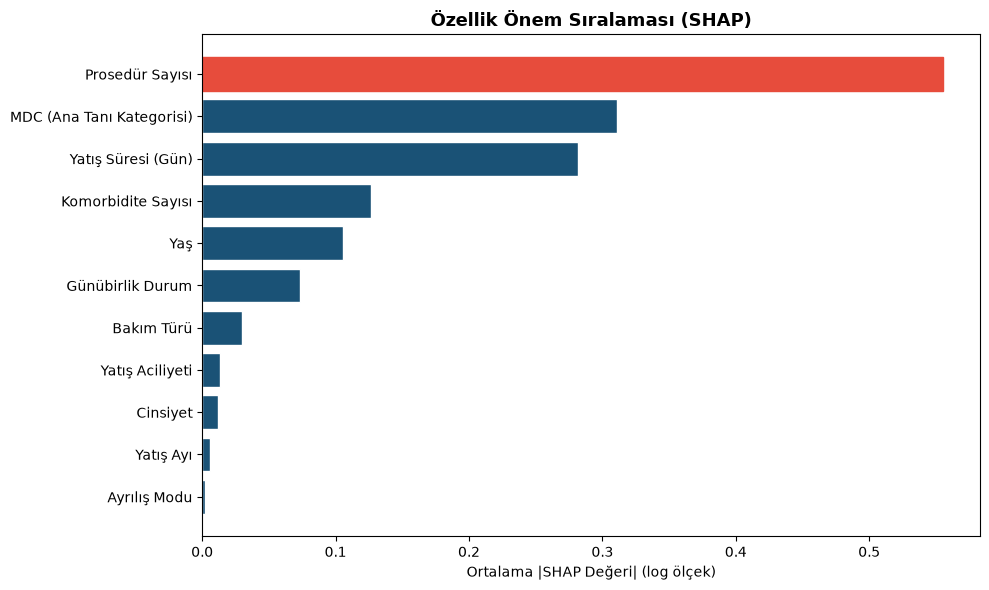

  ✓ Kaydedildi: 04_feature_importance.png

Özellik önem sıralaması (en önemliden en azına):
  Prosedür Sayısı                  ████████████████████ 0.5553
  MDC (Ana Tanı Kategorisi)        ███████████ 0.3109
  Yatış Süresi (Gün)               ██████████ 0.2821
  Komorbidite Sayısı               ████ 0.1268
  Yaş                              ███ 0.1058
  Günübirlik Durum                 ██ 0.0737
  Bakım Türü                       █ 0.0300
  Yatış Aciliyeti                   0.0135
  Cinsiyet                          0.0117
  Yatış Ayı                         0.0060
  Ayrılış Modu                      0.0020


In [10]:
# ─── Bar chart: Ortalama |SHAP| değeri ────────────────
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({
    "feature": display_names,
    "importance": mean_abs_shap
}).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(shap_df["feature"], shap_df["importance"],
               color="#1a5276", edgecolor="white")

# En önemli özelliği vurgula
max_idx = shap_df["importance"].idxmax()
bars[shap_df.index.get_loc(max_idx)].set_color("#e74c3c")

ax.set_xlabel("Ortalama |SHAP Değeri| (log ölçek)")
ax.set_title("Özellik Önem Sıralaması (SHAP)",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig(FIGS / "04_feature_importance.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()
print("  ✓ Kaydedildi: 04_feature_importance.png")

print("\nÖzellik önem sıralaması (en önemliden en azına):")
for _, row in shap_df.sort_values("importance", ascending=False).iterrows():
    bar = "█" * int(row["importance"] / shap_df["importance"].max() * 20)
    print(f"  {row['feature']:<32} {bar} {row['importance']:.4f}")


---
## 4.8 — Model ve Metrikleri Kaydet

Model + metrikler kaydedilince:
- Başka notebook veya script bu modeli yükleyip tahmin yapabilir
- Metrik CSV'si, sunum/rapor için hazır referans


In [11]:
import json, os

# Model kaydet (XGBoost native JSON format)
model_path = ROOT / "reports" / "xgb_model.json"
model.save_model(str(model_path))
print(f"✓ Model kaydedildi  : {model_path.name}  "
      f"({os.path.getsize(model_path)/1024:.1f} KB)")

# Metrik kaydet
metrics = {
    "log_rmse":   round(rmse_log, 4),
    "log_r2":     round(r2_log, 4),
    "aud_rmse":   round(rmse_aud, 2),
    "aud_mae":    round(mae_aud, 2),
    "aud_r2":     round(r2_aud, 4),
    "mape_pct":   round(mape, 2),
    "n_train":    int(len(X_train)),
    "n_test":     int(len(X_test)),
    "best_iter":  int(model.best_iteration + 1),
    "features":   FEATURE_COLS,
    "cv_rmse_mean": round(float(cv_rmse.mean()), 4),
    "cv_rmse_std":  round(float(cv_rmse.std()), 4),
}

metrics_path = ROOT / "reports" / "model_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)
print(f"✓ Metrikler kaydedildi: {metrics_path.name}")

# Özet
print("\n" + "=" * 55)
print("NB4 TAMAMLANDI — MODEL ÖZETİ")
print("=" * 55)
print(f"  Model         : XGBoost Regressor")
print(f"  Hedef         : log1p(total_charge_aud)")
print(f"  Özellik sayısı: {len(FEATURE_COLS)}")
print(f"  Eğitim seti   : {len(X_train):,} epizod")
print(f"  Test seti     : {len(X_test):,} epizod")
print(f"  CV RMSE (log) : {cv_rmse.mean():.4f} ± {cv_rmse.std():.4f}")
print(f"  Test R²       : {r2_aud:.4f}")
print(f"  Test MAE      : ${mae_aud:,.2f}")
print(f"  Test MAPE     : {mape:.1f}%")
print(f"  Best iteration: {model.best_iteration + 1} ağaç")
print("=" * 55)
print("\n→ Sıradaki: NB5 (Çıktılar ve Sunum)")


✓ Model kaydedildi  : xgb_model.json  (585.2 KB)
✓ Metrikler kaydedildi: model_metrics.json

NB4 TAMAMLANDI — MODEL ÖZETİ
  Model         : XGBoost Regressor
  Hedef         : log1p(total_charge_aud)
  Özellik sayısı: 11
  Eğitim seti   : 24,492 epizod
  Test seti     : 6,123 epizod
  CV RMSE (log) : 0.5403 ± 0.0115
  Test R²       : 0.8050
  Test MAE      : $751.39
  Test MAPE     : 24.8%
  Best iteration: 162 ağaç

→ Sıradaki: NB5 (Çıktılar ve Sunum)
